In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, r2_score,
roc_auc_score, roc_curve, mean_squared_error, mean_absolute_error, root_mean_squared_error)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier 
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.under_sampling import RandomUnderSampler
import collections

C:\Anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df_train = pd.read_csv("train_final.csv")

In [3]:
df_test = pd.read_csv("test_final.csv")

In [16]:
df_test.shape

(48744, 119)

In [9]:
df_train['LATE_PAYMENT_MEAN.1'].describe()

count    307511.000000
mean          0.071881
std           0.114234
min           0.000000
25%           0.000000
50%           0.007752
75%           0.103448
max           1.000000
Name: LATE_PAYMENT_MEAN.1, dtype: float64

In [4]:
df_train.drop(columns=['LATE_PAYMENT_MEAN'], inplace=True)
df_test.drop(columns=['LATE_PAYMENT_MEAN'], inplace=True)

In [5]:
df_train.rename(columns={'LATE_PAYMENT_MEAN.1': 'LATE_PAYMENT_MEAN'}, inplace=True)
df_test.rename(columns={'LATE_PAYMENT_MEAN.1': 'LATE_PAYMENT_MEAN'}, inplace=True)

In [6]:
# Replace inf → NaN in FULL dataframe
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_test = df_test.replace([np.inf, -np.inf], np.nan)

# Fill all NaN with 0 (or median if you want)
df_train = df_train.fillna(0)
df_test = df_test.fillna(0)

In [7]:
df_train.to_csv("df_train.csv", index=False)
df_test.to_csv("df_test.csv", index=False)

In [8]:
df_train=pd.read_csv("df_train.csv")
df_test=pd.read_csv("df_train.csv")

In [59]:
df_train['AMT_CREDIT_SUM_SUM'].describe()

count    3.075110e+05
mean     1.675834e+06
std      3.858106e+06
min      0.000000e+00
25%      1.539495e+05
50%      7.110000e+05
75%      1.970993e+06
max      1.017958e+09
Name: AMT_CREDIT_SUM_SUM, dtype: float64

In [9]:
df_train.isnull().sum()

SK_ID_CURR             0
TARGET                 0
NAME_CONTRACT_TYPE     0
CODE_GENDER            0
FLAG_OWN_CAR           0
                      ..
PAYMENT_DELAY_MEAN     0
PAYMENT_DELAY_MAX      0
AMT_INSTALMENT_SUM     0
AMT_INSTALMENT_MEAN    0
AMT_PAYMENT_SUM        0
Length: 118, dtype: int64

In [37]:
df_train.shape

(307511, 118)

In [38]:
pd.set_option('display.max_columns', None)
print(df_train.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'BB_LATE_MEAN', 'BB_SEVERE_LATE_MEAN', 'BB_CLOSED_MEAN',
       'NUM_INSTALMENT_VERSION_NUNIQUE', 'NUM_INSTALMENT_NUMBER_MAX',
       'PAYMENT_DELAY_MEAN', 'PAYMENT_DELAY_MAX', 'AMT_INSTALMENT_SUM',
       'AMT_INSTALMENT_MEAN', 'AMT_PAYMENT_SUM'],
      dtype='str', length=118)


In [8]:
# 1. EXT_SOURCE interactions (these 3 are the strongest predictors in Home Credit)
df_train['EXT_SOURCE_MEAN'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
df_train['EXT_SOURCE_STD'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
# df_train['EXT_SOURCE_MIN'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

# 2. Credit stress indicators
df_train['DEBT_TO_INCOME'] = df_train['AMT_CREDIT_SUM_DEBT_MEAN'] / (df_train['AMT_INCOME_TOTAL'] + 1)
df_train['CREDIT_OVERDUE_RATIO'] = df_train['AMT_CREDIT_SUM_OVERDUE_SUM'] / (df_train['AMT_CREDIT_SUM_SUM'] + 1)
df_train['TOTAL_DEBT_BURDEN'] = (df_train['AMT_ANNUITY'] / (df_train['AMT_INCOME_TOTAL'] + 1))

# 3. Payment behavior (you have installment data)
df_train['PAYMENT_COMPLETION_RATE'] = (df_train['AMT_PAYMENT_SUM'] /(df_train['AMT_INSTALMENT_SUM'] + 1))
df_train['DELAY_TO_CREDIT_RATIO'] = df_train['PAYMENT_DELAY_MEAN'] / (df_train['CNT_PAYMENT_MEAN'] + 1)

# 4. Social circle risk (neighbours defaulting is a signal)
df_train['SOCIAL_CIRCLE_DEFAULT_RATE'] = np.where(df_train['OBS_60_CNT_SOCIAL_CIRCLE'] > 0,
                                        df_train['DEF_60_CNT_SOCIAL_CIRCLE'] / df_train['OBS_60_CNT_SOCIAL_CIRCLE'],np.nan)
df_train['NO_SOCIAL_DATA'] = (df_train['OBS_60_CNT_SOCIAL_CIRCLE'] == 0).astype(int)

# 5. Utilization stress
df_train['UTIL_BALANCE_RATIO'] = (df_train['AMT_BALANCE_SUM'] /(df_train['AMT_CREDIT_LIMIT_ACTUAL_SUM'] + 1))
#df_train['DRAWING_TO_PAYMENT'] = df_train['AMT_DRAWINGS_CURRENT_SUM'] / (df_train['AMT_PAYMENT_SUM'] + 1)

# 6. Stability flags
df_train['IS_EMPLOYED'] = (df_train['DAYS_EMPLOYED'] < 0).astype(int)
df_train['RECENTLY_CHANGED_PHONE'] = (df_train['PHONE_CHANGE_YEARS'] < 1).astype(int)
df_train['HAS_CAR_AND_REALTY'] = ((df_train['FLAG_OWN_CAR'] == 'Y') & (df_train['FLAG_OWN_REALTY'] == 'Y')).astype(int)
df_train['IS_CHRONICALLY_LATE'] = (df_train['SK_DPD_MAX'] > 180).astype(int) 
df_train['HAS_ANY_DELAY'] = (df_train['SK_DPD_MAX'] > 0).astype(int)
#df_train['DELAY_TO_CREDIT_RATIO'] = df_train['PAYMENT_DELAY_MEAN'] / (df_train['CNT_PAYMENT_MEAN'] + 1)
#df_train['DELAY_TO_CREDIT_RATIO'] = df_train['DELAY_TO_CREDIT_RATIO'].clip(0, 5)

In [9]:
df_test['EXT_SOURCE_MEAN'] = df_test[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
df_test['EXT_SOURCE_STD'] = df_test[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
# df_test['EXT_SOURCE_MIN'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

# 2. Credit stress indicators
df_test['DEBT_TO_INCOME'] = df_test['AMT_CREDIT_SUM_DEBT_MEAN'] / (df_test['AMT_INCOME_TOTAL'] + 1)
df_test['CREDIT_OVERDUE_RATIO'] = df_test['AMT_CREDIT_SUM_OVERDUE_SUM'] / (df_test['AMT_CREDIT_SUM_SUM'] + 1)
df_test['TOTAL_DEBT_BURDEN'] = (df_test['AMT_ANNUITY'] / (df_test['AMT_INCOME_TOTAL'] + 1))

# 3. Payment behavior (you have installment data)
df_test['PAYMENT_COMPLETION_RATE'] = (df_test['AMT_PAYMENT_SUM'] /(df_test['AMT_INSTALMENT_SUM'] + 1))
df_test['DELAY_TO_CREDIT_RATIO'] = df_test['PAYMENT_DELAY_MEAN'] / (df_test['CNT_PAYMENT_MEAN'] + 1)

# 4. Social circle risk (neighbours defaulting is a signal)
df_test['SOCIAL_CIRCLE_DEFAULT_RATE'] = np.where(df_test['OBS_60_CNT_SOCIAL_CIRCLE'] > 0,
                                        df_test['DEF_60_CNT_SOCIAL_CIRCLE'] / df_test['OBS_60_CNT_SOCIAL_CIRCLE'],np.nan)
df_test['NO_SOCIAL_DATA'] = (df_test['OBS_60_CNT_SOCIAL_CIRCLE'] == 0).astype(int)

# 5. Utilization stress
df_test['UTIL_BALANCE_RATIO'] = (df_test['AMT_BALANCE_SUM'] /(df_test['AMT_CREDIT_LIMIT_ACTUAL_SUM'] + 1))
#df_test['DRAWING_TO_PAYMENT'] = df_test['AMT_DRAWINGS_CURRENT_SUM'] / (df_test['AMT_PAYMENT_SUM'] + 1)

# 6. Stability flags
df_test['IS_EMPLOYED'] = (df_test['DAYS_EMPLOYED'] < 0).astype(int)
df_test['RECENTLY_CHANGED_PHONE'] = (df_test['PHONE_CHANGE_YEARS'] < 1).astype(int)
df_test['HAS_CAR_AND_REALTY'] = ((df_test['FLAG_OWN_CAR'] == 'Y') & (df_test['FLAG_OWN_REALTY'] == 'Y')).astype(int)
df_test['IS_CHRONICALLY_LATE'] = (df_test['SK_DPD_MAX'] > 180).astype(int) 
df_test['HAS_ANY_DELAY'] = (df_test['SK_DPD_MAX'] > 0).astype(int)
#df_test['DELAY_TO_CREDIT_RATIO'] = df_test['PAYMENT_DELAY_MEAN'] / (df_test['CNT_PAYMENT_MEAN'] + 1)
#df_test['DELAY_TO_CREDIT_RATIO'] = df_test['DELAY_TO_CREDIT_RATIO'].clip(0, 5)

In [34]:
df_train.shape

(307511, 132)

In [35]:
for col in df_train.columns:
    if col.endswith('_x'):
        base = col[:-2]
        if base + '_y' in df_train.columns:
            print(base)

In [19]:
# Drop ID
df_train = df_train.drop(columns=['SK_ID_CURR'])

# Encode
bool_cols = df_train.select_dtypes(include='bool').columns
df_train[bool_cols] = df_train[bool_cols].astype(int)
cat_cols = df_train.select_dtypes(include='category').columns
df_train[cat_cols] = df_train[cat_cols].astype(object)
df_train = pd.get_dummies(df_train, drop_first=True)
df_train.columns = df_train.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

In [12]:
X_full = df_train.drop('TARGET', axis=1)
y_full = df_train['TARGET']

rus = RandomUnderSampler(sampling_strategy={0: 28500, 1: 19000}, random_state=42)
X_rus, y_rus = rus.fit_resample(X_full, y_full)
print("After undersampling:", collections.Counter(y_rus))

X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42, stratify=y_rus)

After undersampling: Counter({0: 28500, 1: 19000})


In [13]:
import lightgbm as lgb
temp_model = lgb.LGBMClassifier(n_estimators=200, random_state=42)
temp_model.fit(X_train, y_train)

importance = pd.Series(temp_model.feature_importances_, index=X_train.columns)
top_features = importance.nlargest(60).index

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19432
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465


In [14]:
model_final = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=1.5,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model_final.fit(X_train_top, y_train)

y_pred = model_final.predict(X_test_top)
y_proba = model_final.predict_proba(X_test_top)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13692
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
              precision    recall  f1-score   support

           0       0.78      0.73      0.75      5700
           1       0.63      0.68      0.65      3800

    accuracy                           0.71      9500
   macro avg       0.70      0.71      0.70      9500
weighted avg       0.72      0.71      0.71      9500

AUC-ROC: 0.768576731301939


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'num_leaves': [31, 63],
    'learning_rate': [0.03, 0.05],
    'min_child_samples': [20, 50],
    'scale_pos_weight': [1.5, 1.75, 2]
}

grid_model = lgb.LGBMClassifier(random_state=42)

grid_search = GridSearchCV(
    grid_model,
    param_grid,
    cv=3,
    scoring='f1',        # optimizing for minority class F1
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_top, y_train)

print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_top)
y_proba_grid = best_model.predict_proba(X_test_top)[:, 1]

print(classification_report(y_test, y_pred_grid))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_grid))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030707 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13692
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
Best params: {'learning_rate': 0.05, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31, 'scale_pos_weight': 2}
Best F1: 0.6610350924757452
              precision    recall  f1-score   support

           0       0.81      0.63      0.71      5700
           1       0.58      0.77      0.66      3800

    accuracy                           0.69      9500
   macro avg       0.69      0.70      0.69      9500
weighted avg       

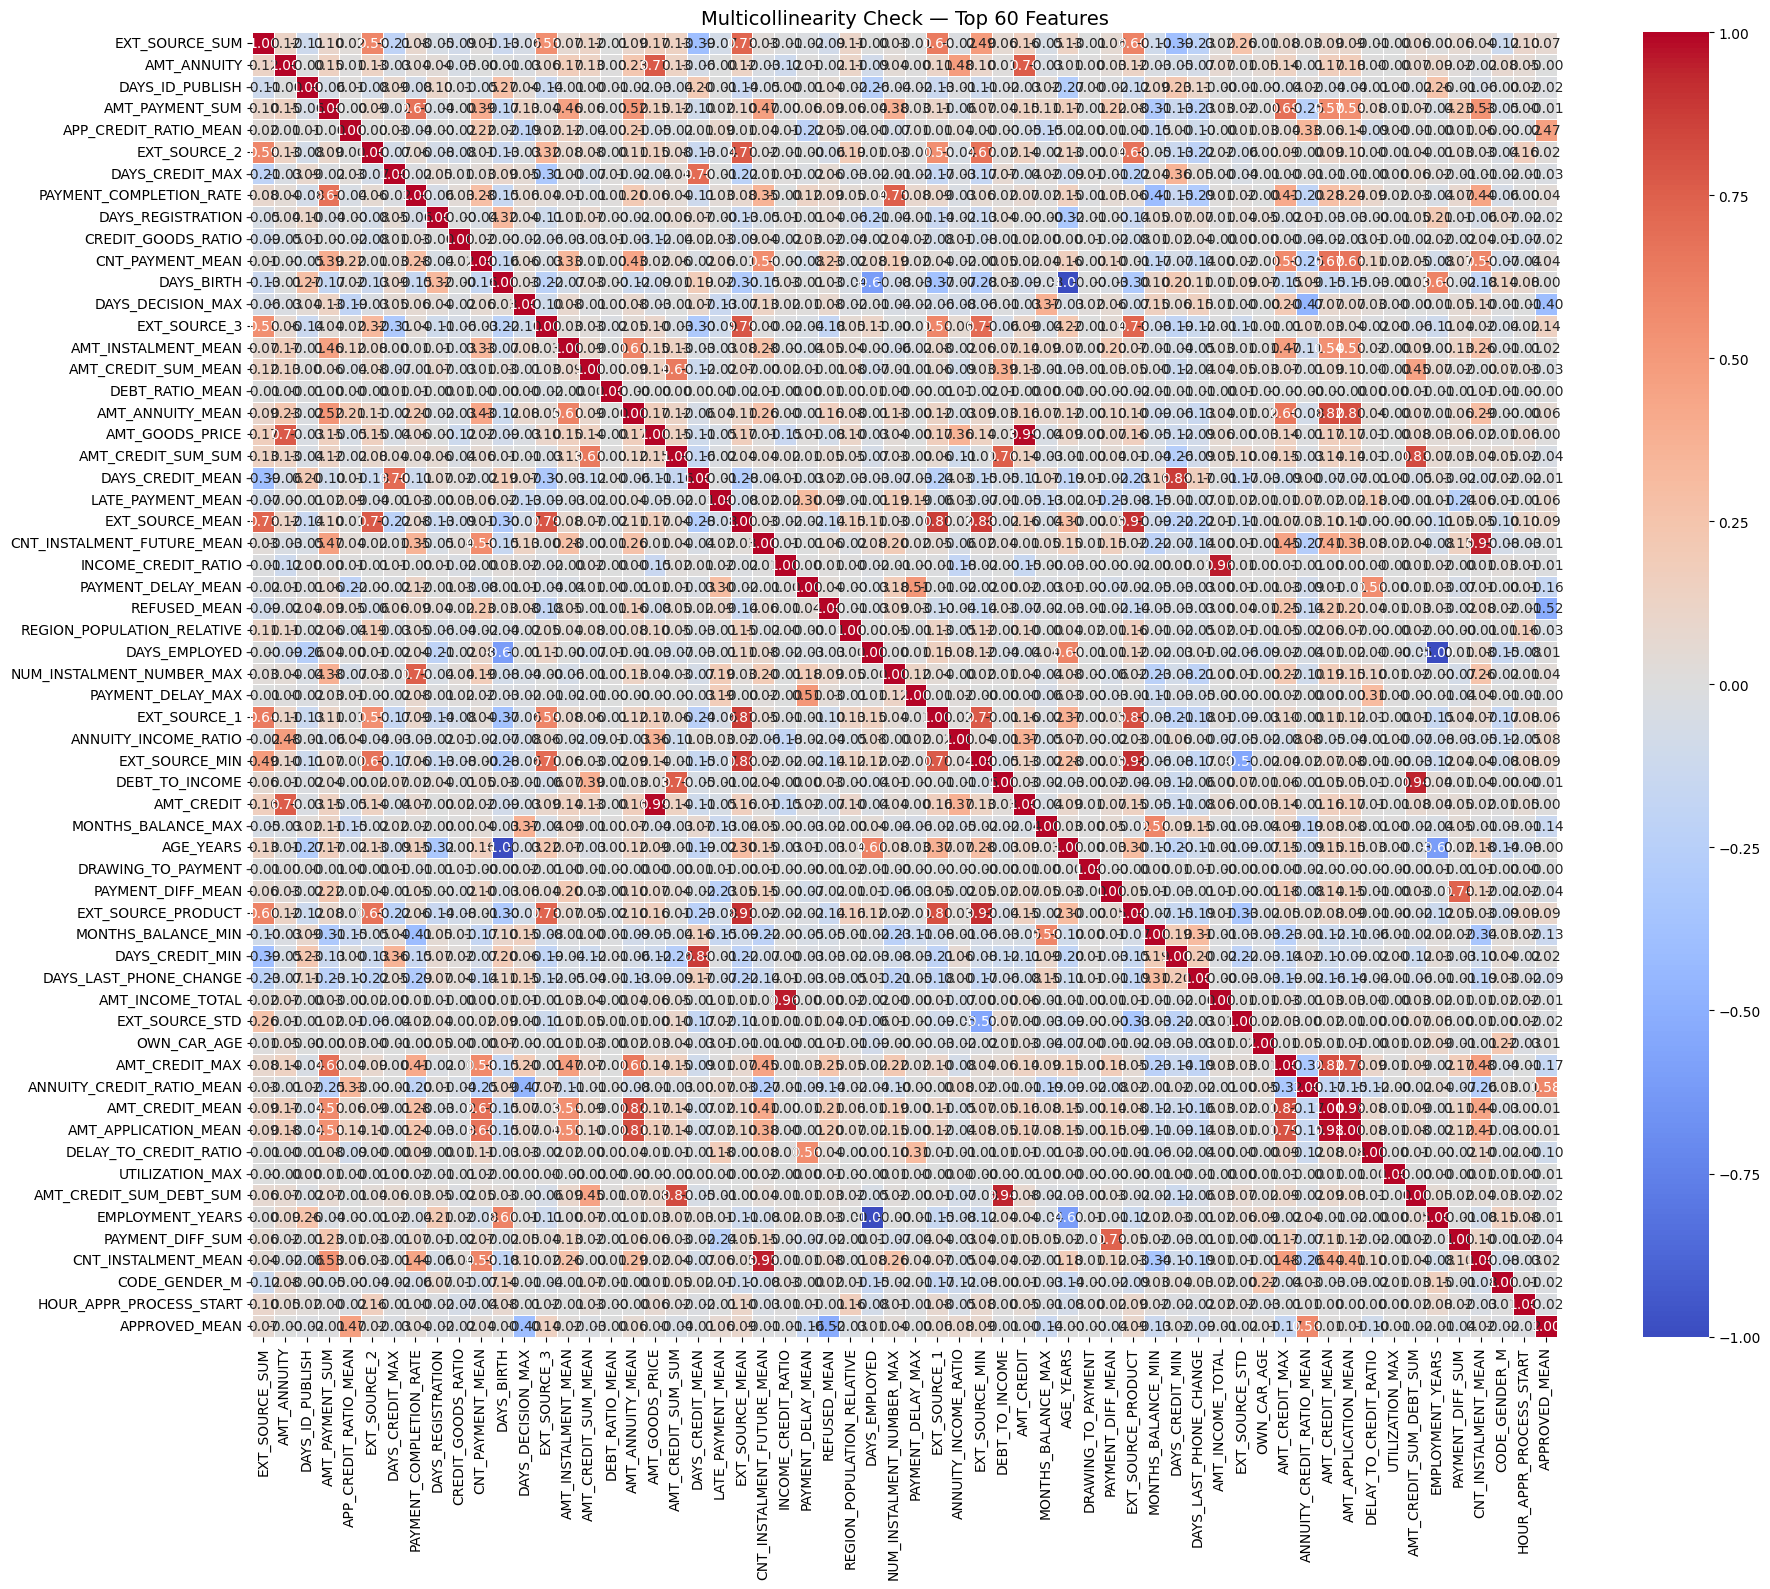


⚠️ Highly correlated pairs (|correlation| > 0.8):
DAYS_BIRTH ↔ AGE_YEARS: -1.00
AMT_ANNUITY_MEAN ↔ AMT_CREDIT_MEAN: 0.82
AMT_ANNUITY_MEAN ↔ AMT_APPLICATION_MEAN: 0.81
AMT_GOODS_PRICE ↔ AMT_CREDIT: 0.99
AMT_CREDIT_SUM_SUM ↔ AMT_CREDIT_SUM_DEBT_SUM: 0.83
DAYS_CREDIT_MEAN ↔ DAYS_CREDIT_MIN: 0.88
EXT_SOURCE_MEAN ↔ EXT_SOURCE_1: 0.87
EXT_SOURCE_MEAN ↔ EXT_SOURCE_MIN: 0.88
EXT_SOURCE_MEAN ↔ EXT_SOURCE_PRODUCT: 0.91
CNT_INSTALMENT_FUTURE_MEAN ↔ CNT_INSTALMENT_MEAN: 0.95
INCOME_CREDIT_RATIO ↔ AMT_INCOME_TOTAL: 0.96
DAYS_EMPLOYED ↔ EMPLOYMENT_YEARS: -1.00
EXT_SOURCE_1 ↔ EXT_SOURCE_PRODUCT: 0.81
EXT_SOURCE_MIN ↔ EXT_SOURCE_PRODUCT: 0.92
DEBT_TO_INCOME ↔ AMT_CREDIT_SUM_DEBT_SUM: 0.94
AMT_CREDIT_MAX ↔ AMT_CREDIT_MEAN: 0.82
AMT_CREDIT_MEAN ↔ AMT_APPLICATION_MEAN: 0.98


In [16]:
corr = X_train_top.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Multicollinearity Check — Top 60 Features', fontsize=14)
plt.tight_layout()
plt.show()

# Danger zone pairs
print("\n⚠️ Highly correlated pairs (|correlation| > 0.8):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.8:
            print(f"{corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i,j]:.2f}")

In [17]:
cols_to_drop = [
    'DAYS_BIRTH',           # AGE_YEARS is cleaner
    'DAYS_EMPLOYED',        # EMPLOYMENT_YEARS is cleaner
    'AMT_GOODS_PRICE',      # 0.99 with AMT_CREDIT
    'EXT_SOURCE_MEAN',      # redundant with EXT_SOURCE_MIN
    'EXT_SOURCE_PRODUCT',   # redundant with EXT_SOURCE_MIN
    'AMT_APPLICATION_MEAN', # 0.98 with AMT_CREDIT_MEAN
    'AMT_CREDIT_MAX',       # 0.82 with AMT_CREDIT_MEAN
    'AMT_INCOME_TOTAL',     # keeping INCOME_CREDIT_RATIO instead
    'AMT_CREDIT_SUM_DEBT_SUM', # keeping DEBT_TO_INCOME instead
    'CNT_INSTALMENT_MEAN',  # 0.95 with CNT_INSTALMENT_FUTURE_MEAN
    'DAYS_CREDIT_MIN',      # 0.88 with DAYS_CREDIT_MEAN
]

X_train_top = X_train_top.drop(columns=[c for c in cols_to_drop if c in X_train_top.columns])
X_test_top = X_test_top.drop(columns=[c for c in cols_to_drop if c in X_test_top.columns])

print("Remaining features:", X_train_top.shape[1])

Remaining features: 49


## Train and predict on top 49 features

In [10]:
model_final = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=1.5,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model_final.fit(X_train_top, y_train)

y_pred = model_final.predict(X_test_top)
y_proba = model_final.predict_proba(X_test_top)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11011
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      5700
           1       0.62      0.69      0.65      3800

    accuracy                           0.71      9500
   macro avg       0.70      0.70      0.70      9500
weighted avg       0.71      0.71      0.71      9500

AUC-ROC: 0.7674143582640812


In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'num_leaves': [31, 63],
    'learning_rate': [0.03, 0.05],
    'min_child_samples': [20, 50],
    'scale_pos_weight': [1.5, 1.75, 2]
}

grid_model = lgb.LGBMClassifier(random_state=42)

# RandomizedSearchCV only tries 20 combinations instead of all 144
random_search = RandomizedSearchCV(
    grid_model, param_grid,
    n_iter=20,
    cv=3, scoring='f1',
    n_jobs=-1, verbose=1,
    random_state=42
)

random_search.fit(X_train_top, y_train)

print("Best params:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_top)
y_proba = best_model.predict_proba(X_test_top)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11011
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
Best params: {'scale_pos_weight': 2, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'learning_rate': 0.05}
              precision    recall  f1-score   support

           0       0.80      0.62      0.70      5700
           1       0.58      0.77      0.66      3800

    accuracy                           0.68      9500
   macro avg       0.69      0.70      0.68      9500
weighted avg       0.71      0.68      0.68     

## Recalculated top 60 features

In [11]:
# Retrain temp model on reduced features
temp_model2 = lgb.LGBMClassifier(n_estimators=200, random_state=42)
temp_model2.fit(X_train_top, y_train)

# New feature importance on cleaned set
importance2 = pd.Series(temp_model2.feature_importances_, index=X_train_top.columns)
top_features2 = importance2.nlargest(50).index

X_train_final = X_train_top[top_features2]
X_test_final = X_test_top[top_features2]


[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11011
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465


In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'num_leaves': [31, 63],
    'learning_rate': [0.03, 0.05],
    'min_child_samples': [20, 50],
    'scale_pos_weight': [1.5, 1.75, 2]
}

grid_model = lgb.LGBMClassifier(random_state=42)

# RandomizedSearchCV only tries 20 combinations instead of all 144
random_search = RandomizedSearchCV(
    grid_model, param_grid,
    n_iter=20,
    cv=3, scoring='f1',
    n_jobs=-1, verbose=1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best params:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_final)
y_proba = best_model.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11011
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
Best params: {'scale_pos_weight': 2, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'learning_rate': 0.05}
              precision    recall  f1-score   support

           0       0.80      0.62      0.70      5700
           1       0.58      0.77      0.66      3800

    accuracy                           0.68      9500
   macro avg       0.69      0.70      0.68      9500
weighted avg       0.71      0.68      0.68     

In [12]:
model_final = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=1.5,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model_final.fit(X_train_final, y_train)

y_pred = model_final.predict(X_test_final)
y_proba = model_final.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016468 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11011
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      5700
           1       0.62      0.69      0.65      3800

    accuracy                           0.71      9500
   macro avg       0.70      0.70      0.70      9500
weighted avg       0.71      0.71      0.71      9500

AUC-ROC: 0.7674108494921514


In [48]:
df_train=pd.read_csv("df_train.csv")

In [49]:
# 1. EXT_SOURCE interactions (these 3 are the strongest predictors in Home Credit)
df_train['EXT_SOURCE_PRODUCT'] = df_train['EXT_SOURCE_1'] * df_train['EXT_SOURCE_2'] * df_train['EXT_SOURCE_3']
df_train['EXT_SOURCE_STD'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
df_train['EXT_SOURCE_MIN'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

# 2. Credit stress indicators
df_train['DEBT_TO_INCOME'] = df_train['AMT_CREDIT_SUM_DEBT_SUM'] / (df_train['AMT_INCOME_TOTAL'] + 1)
df_train['CREDIT_OVERDUE_RATIO'] = df_train['AMT_CREDIT_SUM_OVERDUE_SUM'] / (df_train['AMT_CREDIT_SUM_SUM'] + 1)
df_train['TOTAL_DEBT_BURDEN'] = ((df_train['AMT_ANNUITY'] / (df_train['AMT_INCOME_TOTAL'] + 1))

# 3. Payment behavior (you have installment data)
df_train['PAYMENT_COMPLETION_RATE'] = (df_train['AMT_PAYMENT_SUM'] /(df_train['AMT_INSTALMENT_SUM'] + 1))
df_train['DELAY_TO_CREDIT_RATIO'] = df_train['PAYMENT_DELAY_MEAN'] / (df_train['CNT_PAYMENT_MEAN'] + 1)

# 4. Social circle risk (neighbours defaulting is a signal)
df_train['SOCIAL_CIRCLE_DEFAULT_RATE'] = np.where(df_train['OBS_60_CNT_SOCIAL_CIRCLE'] > 0,
                                        df_train['DEF_60_CNT_SOCIAL_CIRCLE'] / df_train['OBS_60_CNT_SOCIAL_CIRCLE'],np.nan)
df_train['NO_SOCIAL_DATA'] = (df_train['OBS_60_CNT_SOCIAL_CIRCLE'] == 0).astype(int)

# 5. Utilization stress
df_train['UTIL_BALANCE_RATIO'] = (df_train['AMT_BALANCE_SUM'] /(df_train['AMT_CREDIT_LIMIT_ACTUAL_SUM'] + 1))
#df_train['DRAWING_TO_PAYMENT'] = df_train['AMT_DRAWINGS_CURRENT_SUM'] / (df_train['AMT_PAYMENT_SUM'] + 1)

# 6. Stability flags
df_train['IS_EMPLOYED'] = (df_train['DAYS_EMPLOYED'] < 0).astype(int)
df_train['RECENTLY_CHANGED_PHONE'] = (df_train['PHONE_CHANGE_YEARS'] < 1).astype(int)
df_train['HAS_CAR_AND_REALTY'] = ((df_train['FLAG_OWN_CAR'] == 'Y') & (df_train['FLAG_OWN_REALTY'] == 'Y')).astype(int)

#df_train['DELAY_TO_CREDIT_RATIO'] = df_train['PAYMENT_DELAY_MEAN'] / (df_train['CNT_PAYMENT_MEAN'] + 1)
#df_train['DELAY_TO_CREDIT_RATIO'] = df_train['DELAY_TO_CREDIT_RATIO'].clip(0, 5)

In [37]:
# Drop ID
df_train = df_train.drop(columns=['SK_ID_CURR'])

# Encode
bool_cols = df_train.select_dtypes(include='bool').columns
df_train[bool_cols] = df_train[bool_cols].astype(int)
cat_cols = df_train.select_dtypes(include='category').columns
df_train[cat_cols] = df_train[cat_cols].astype(object)
df_train = pd.get_dummies(df_train, drop_first=True)
df_train.columns = df_train.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

In [17]:
X_full_top = df_train.drop('TARGET', axis=1)
y_full_target = df_train['TARGET']

# Keep only the important columns from your final feature set
#X_full_top = X_full_top[X_train_final.columns]

# Split — no undersampling, full imbalanced data
X_tr, X_te, y_tr, y_te = train_test_split(
    X_full_top, y_full_target,
    test_size=0.2, random_state=42, stratify=y_full_target
)

# Train with scale_pos_weight to handle imbalance
model_full = lgb.LGBMClassifier(
    n_estimators=1000,
    scale_pos_weight=15,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=50,
    random_state=42
)

model_full.fit(X_tr, y_tr)

y_proba_full = model_full.predict_proba(X_te)[:, 1]
y_pred_full = model_full.predict(X_te)

print(classification_report(y_te, y_pred_full))
print("Full data AUC-ROC:", roc_auc_score(y_te, y_proba_full))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.286807 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20153
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 223
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     56538
           1       0.19      0.67      0.30      4965

    accuracy                           0.74     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.74      0.80     61503

Full data AUC-ROC: 0.7814690452111329


In [19]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_te, (y_proba_full >= t).astype(int), pos_label=1) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_threshold)

y_pred_best = (y_proba_full >= best_threshold).astype(int)
print(classification_report(y_te, y_pred_best))
print("AUC-ROC:", roc_auc_score(y_te, y_proba_full))

Best threshold: 0.6500000000000001
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.26      0.48      0.33      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.68      0.62     61503
weighted avg       0.89      0.85      0.87     61503

AUC-ROC: 0.7814690452111329


In [20]:
#Yeah this is the imbalance problem hitting hard again — 56k vs 4.9k is brutal on precision.

#**Best of both worlds — combine full data AUC with undersampling's F1.** Here's the plan:

#Train TWO models and blend their probabilities:

#python
# Model 1 — full data (good AUC)
# already have y_proba_full

# Model 2 — undersampled data (good F1)
# already have y_proba from your earlier model

# BUT they have different test sets so we need one consistent test set
# Use the full data test set (X_te, y_te) for both
# Retrain undersampled model and predict on X_te

model_us = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=1.75,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

# undersample only training data
rus2 = RandomUnderSampler(sampling_strategy={0: 28500, 1: 19000}, random_state=42)
X_tr_us, y_tr_us = rus2.fit_resample(X_tr, y_tr)

model_us.fit(X_tr_us, y_tr_us)
y_proba_us = model_us.predict_proba(X_te)[:, 1]

# Blend
y_proba_blend = (y_proba_full * 0.6) + (y_proba_us * 0.4)

# Threshold tune on blend
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_te, (y_proba_blend >= t).astype(int), pos_label=1) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_blend = (y_proba_blend >= best_threshold).astype(int)
print("Best threshold:", best_threshold)
print(classification_report(y_te, y_pred_blend))
print("Blended AUC-ROC:", roc_auc_score(y_te, y_proba_blend))

#This should give you **0.78+ AUC AND better F1/precision** together. Run it!

[LightGBM] [Info] Number of positive: 19000, number of negative: 28500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19707
[LightGBM] [Info] Number of data points in the train set: 47500, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
Best threshold: 0.7000000000000002
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     56538
           1       0.28      0.42      0.34      4965

    accuracy                           0.87     61503
   macro avg       0.61      0.66      0.63     61503
weighted avg       0.89      0.87      0.88     61503

Blended AUC-ROC: 0.7841128445298418


In [23]:
!pip install catboost
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=15,  # full imbalance ratio
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cat_model.fit(X_tr, y_tr, eval_set=(X_te, y_te))

y_proba_cat = cat_model.predict_proba(X_te)[:, 1]
print("CatBoost AUC-ROC:", roc_auc_score(y_te, y_proba_cat))

# Blend with LightGBM full model
y_proba_blend2 = (y_proba_full * 0.5) + (y_proba_cat * 0.5)
print("Blended AUC-ROC:", roc_auc_score(y_te, y_proba_blend2))

#Run it — expect CatBoost solo to hit 0.78-0.79 and the blend to potentially touch 0.79-0.80!

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.2 MB/s eta 0:00:45
    --------------------------------------- 1.3/100.2 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 1.8/100.2 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 2.9/100.2 MB 2.0 MB/s eta 0:00:49
   - -------------------------------------- 3.4/100.2 MB 2.1 MB/s eta 0:00:46
   - -------------------------------------- 3.9/100.2 MB 2.2 MB/s eta 0:00:44
   - -------------------------------------- 4.5/100.2 MB 2.2 MB/s eta 0:00:44
   - ---------

In [24]:
# Threshold tune for best F1
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_te, (y_proba_cat >= t).astype(int), pos_label=1) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_cat = (y_proba_cat >= best_threshold).astype(int)
print("Best threshold:", best_threshold)
print(classification_report(y_te, y_pred_cat))
print("CatBoost AUC-ROC:", roc_auc_score(y_te, y_proba_cat))

# Same for blend
f1_scores_blend = [f1_score(y_te, (y_proba_blend2 >= t).astype(int), pos_label=1) for t in thresholds]
best_threshold_blend = thresholds[np.argmax(f1_scores_blend)]

y_pred_blend2 = (y_proba_blend2 >= best_threshold_blend).astype(int)
print("\n--- Blended Model ---")
print("Best threshold:", best_threshold_blend)
print(classification_report(y_te, y_pred_blend2))
print("Blended AUC-ROC:", roc_auc_score(y_te, y_proba_blend2))


Best threshold: 0.7000000000000002
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.26      0.48      0.34      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.68      0.63     61503
weighted avg       0.89      0.85      0.87     61503

CatBoost AUC-ROC: 0.785231036584686

--- Blended Model ---
Best threshold: 0.7000000000000002
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     56538
           1       0.28      0.43      0.34      4965

    accuracy                           0.86     61503
   macro avg       0.61      0.67      0.63     61503
weighted avg       0.89      0.86      0.88     61503

Blended AUC-ROC: 0.7858262996802016


In [26]:
df_train.shape

(307511, 231)

In [38]:
# Undersample full dataset — NO feature selection
X_full = df_train.drop('TARGET', axis=1)
y_full = df_train['TARGET']

rus = RandomUnderSampler(sampling_strategy={0: 28500, 1: 19000}, random_state=42)
X_rus, y_rus = rus.fit_resample(X_full, y_full)
print("After undersampling:", collections.Counter(y_rus))

X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42, stratify=y_rus
)

model_all = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=1.5,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model_all.fit(X_train, y_train)

y_pred_all = model_all.predict(X_test)
y_proba_all = model_all.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_all))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_all))

After undersampling: Counter({0: 28500, 1: 19000})
[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19432
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
              precision    recall  f1-score   support

           0       0.78      0.73      0.75      5700
           1       0.63      0.69      0.66      3800

    accuracy                           0.71      9500
   macro avg       0.70      0.71      0.71      9500
weighted avg       0.72      0.71      0.71      9500

AUC-ROC: 0.7756271468144044


In [39]:
corr_matrix = X_full.corr().abs()

In [40]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [41]:
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Columns to drop:", len(to_drop))
print(to_drop)  # preview

Columns to drop: 18
['AMT_GOODS_PRICE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'CHILDREN_RATIO', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 'PHONE_CHANGE_YEARS', 'CNT_INSTALMENT_FUTURE_MEAN', 'SK_DPD_MEAN', 'AMT_CREDIT_MEAN', 'AMT_BALANCE_MAX', 'AMT_PAYMENT_CURRENT_SUM', 'AMT_TOTAL_RECEIVABLE_MEAN', 'EXT_SOURCE_PRODUCT', 'EXT_SOURCE_MIN', 'UTIL_BALANCE_RATIO', 'IS_EMPLOYED', 'NAME_INCOME_TYPE_Pensioner', 'ORGANIZATION_TYPE_XNA']


In [43]:
cols_to_drop_manual = [
    'DAYS_BIRTH','DAYS_EMPLOYED','DAYS_LAST_PHONE_CHANGE','AMT_GOODS_PRICE', 'OBS_60_CNT_SOCIAL_CIRCLE', 
    'CHILDREN_RATIO','CNT_INSTALMENT_FUTURE_MEAN', 'SK_DPD_MEAN', 'AMT_CREDIT_MEAN', 'AMT_BALANCE_MAX', 
    'AMT_PAYMENT_CURRENT_SUM', 'AMT_TOTAL_RECEIVABLE_MEAN', 'EXT_SOURCE_PRODUCT', 'EXT_SOURCE_MIN', 
    'UTIL_BALANCE_RATIO', 'IS_EMPLOYED','NAME_INCOME_TYPE_Pensioner','ORGANIZATION_TYPE_XNA'
]

X_full = X_full.drop(columns=cols_to_drop_manual)

In [96]:
X_full = X_full.drop(columns=to_drop)

KeyError: "['AMT_GOODS_PRICE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'CHILDREN_RATIO', 'CNT_INSTALMENT_FUTURE_MEAN', 'SK_DPD_MEAN', 'AMT_CREDIT_MEAN', 'AMT_BALANCE_MAX', 'AMT_PAYMENT_CURRENT_SUM', 'AMT_TOTAL_RECEIVABLE_MEAN', 'EXT_SOURCE_PRODUCT', 'EXT_SOURCE_MIN', 'UTIL_BALANCE_RATIO', 'IS_EMPLOYED', 'NAME_INCOME_TYPE_Pensioner', 'ORGANIZATION_TYPE_XNA'] not found in axis"

In [97]:
X_full.shape

(307511, 212)

In [45]:
rus = RandomUnderSampler(sampling_strategy={0: 28500, 1: 19000}, random_state=42)
X_rus, y_rus = rus.fit_resample(X_full, y_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42, stratify=y_rus
)

model = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=1.5,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16131
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 199
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
              precision    recall  f1-score   support

           0       0.78      0.73      0.75      5700
           1       0.63      0.69      0.66      3800

    accuracy                           0.71      9500
   macro avg       0.70      0.71      0.70      9500
weighted avg       0.72      0.71      0.71      9500

AUC-ROC: 0.7755159279778394


In [8]:
df_train=pd.read_csv("df_train.csv")
df_test=pd.read_csv("df_test.csv")

In [19]:
df_train.shape

(307511, 116)

In [20]:
df_test.shape

(48744, 116)

In [100]:
# 1. EXT_SOURCE interactions (these 3 are the strongest predictors in Home Credit)
df_train['EXT_SOURCE_MEAN'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
df_train['EXT_SOURCE_STD'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
# df_train['EXT_SOURCE_MIN'] = df_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

# 2. Credit stress indicators
df_train['DEBT_TO_INCOME'] = df_train['AMT_CREDIT_SUM_DEBT_MEAN'] / (df_train['AMT_INCOME_TOTAL'] + 1)
df_train['CREDIT_OVERDUE_RATIO'] = df_train['AMT_CREDIT_SUM_OVERDUE_SUM'] / (df_train['AMT_CREDIT_SUM_SUM'] + 1)
df_train['TOTAL_DEBT_BURDEN'] = (df_train['AMT_ANNUITY'] / (df_train['AMT_INCOME_TOTAL'] + 1))

# 3. Payment behavior (you have installment data)
df_train['PAYMENT_COMPLETION_RATE'] = (df_train['AMT_PAYMENT_SUM'] /(df_train['AMT_INSTALMENT_SUM'] + 1))
df_train['DELAY_TO_CREDIT_RATIO'] = df_train['PAYMENT_DELAY_MEAN'] / (df_train['CNT_PAYMENT_MEAN'] + 1)

# 4. Social circle risk (neighbours defaulting is a signal)
df_train['SOCIAL_CIRCLE_DEFAULT_RATE'] = np.where(df_train['OBS_60_CNT_SOCIAL_CIRCLE'] > 0,
                                        df_train['DEF_60_CNT_SOCIAL_CIRCLE'] / df_train['OBS_60_CNT_SOCIAL_CIRCLE'],np.nan)
df_train['NO_SOCIAL_DATA'] = (df_train['OBS_60_CNT_SOCIAL_CIRCLE'] == 0).astype(int)

# 5. Utilization stress
df_train['UTIL_BALANCE_RATIO'] = (df_train['AMT_BALANCE_SUM'] /(df_train['AMT_CREDIT_LIMIT_ACTUAL_SUM'] + 1))
#df_train['DRAWING_TO_PAYMENT'] = df_train['AMT_DRAWINGS_CURRENT_SUM'] / (df_train['AMT_PAYMENT_SUM'] + 1)

# 6. Stability flags
df_train['IS_EMPLOYED'] = (df_train['DAYS_EMPLOYED'] < 0).astype(int)
df_train['RECENTLY_CHANGED_PHONE'] = (df_train['PHONE_CHANGE_YEARS'] < 1).astype(int)
df_train['HAS_CAR_AND_REALTY'] = ((df_train['FLAG_OWN_CAR'] == 'Y') & (df_train['FLAG_OWN_REALTY'] == 'Y')).astype(int)

#df_train['DELAY_TO_CREDIT_RATIO'] = df_train['PAYMENT_DELAY_MEAN'] / (df_train['CNT_PAYMENT_MEAN'] + 1)
#df_train['DELAY_TO_CREDIT_RATIO'] = df_train['DELAY_TO_CREDIT_RATIO'].clip(0, 5)

In [101]:
df_train.shape

(307511, 130)

In [20]:
num_cols = df_train.select_dtypes(include=[np.number]).columns

corr_matrix = df_train[num_cols].corr().abs()

In [21]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [22]:
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Corr drop:", len(to_drop_corr))
print(to_drop_corr[:20])

Corr drop: 17
['AMT_GOODS_PRICE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'CHILDREN_RATIO', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 'PHONE_CHANGE_YEARS', 'CNT_INSTALMENT_FUTURE_MEAN', 'SK_DPD_MEAN', 'AMT_CREDIT_MEAN', 'AMT_BALANCE_MAX', 'AMT_PAYMENT_CURRENT_SUM', 'AMT_TOTAL_RECEIVABLE_MEAN', 'AMT_PAYMENT_SUM', 'EXT_SOURCE_PRODUCT', 'TOTAL_DEBT_BURDEN', 'UTIL_BALANCE_RATIO', 'IS_EMPLOYED']


In [10]:
cols_to_drop_manual = [
    'DAYS_BIRTH','DAYS_EMPLOYED','DAYS_LAST_PHONE_CHANGE',
    'CHILDREN_RATIO','CNT_INSTALMENT_FUTURE_MEAN',
    'SK_DPD_MEAN','AMT_BALANCE_MAX','AMT_PAYMENT_CURRENT_SUM',
    'AMT_TOTAL_RECEIVABLE_MEAN','SK_DPD_MAX'
    ]

final_drop_cols = list(set(cols_to_drop_manual))

df_train = df_train.drop(columns=final_drop_cols)
df_test = df_test.drop(columns=final_drop_cols)

In [11]:
df_train.to_csv("final_clean_train.csv", index=False)
df_test.to_csv("final_clean_test.csv", index=False)

In [26]:
df_test.shape

(48744, 122)

In [26]:
df_test.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
DELAY_TO_CREDIT_RATIO         0
SOCIAL_CIRCLE_DEFAULT_RATE    0
DRAWING_TO_PAYMENT            0
RECENTLY_CHANGED_PHONE        0
HAS_CAR_AND_REALTY            0
Length: 114, dtype: int64

In [108]:
df_train.shape

(307511, 114)

In [41]:
X = df_train.drop(['TARGET','SK_ID_CURR'], axis=1)
y = df_train['TARGET']

In [42]:
X = pd.get_dummies(X)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
# 2. CLEAN COLUMN NAMES (do this FIRST before anything)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

# 3. UNDERSAMPLE
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy={0: 28500, 1: 19000}, random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

# 4. SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus,
    test_size=0.2,
    random_state=42,
    stratify=y_rus
)

# 5. MODEL
import lightgbm as lgb
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=1.5,
    random_state=42
)

# 6. TRAIN
model.fit(X_train, y_train)

# 7. PREDICT
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 8. EVALUATE
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 15200, number of negative: 22800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17449
[LightGBM] [Info] Number of data points in the train set: 38000, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400000 -> initscore=-0.405465
[LightGBM] [Info] Start training from score -0.405465
              precision    recall  f1-score   support

         0.0       0.78      0.73      0.75      5700
         1.0       0.63      0.69      0.66      3800

    accuracy                           0.71      9500
   macro avg       0.70      0.71      0.71      9500
weighted avg       0.72      0.71      0.71      9500

AUC-ROC: 0.7754535087719299
